# Figure 3 — Annotation Overlap and Database Coverage

Venn diagrams compare InChIKey overlap between cassava and cocoyam annotations. UpSet plots show which database combinations (PubChem, HMDB, ChEBI, etc.) annotate each feature. Bar plots highlight selected metabolites with significant changes upon fermentation.

**Output:** `figure3_standardized.svg / .png`

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from upsetplot import UpSet, from_memberships
from matplotlib_venn import venn2, venn2_circles
import os

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'

# Output directory
OUTPUT_DIR = '../figures/separate_treatment'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Analysis parameters
PROB_CUTOFF = 0.7
FDR_CUTOFF = 0.05
LOG2FC_THRESHOLD = 1.0

print(f"Output directory: {OUTPUT_DIR}")
print(f"Probability cutoff: {PROB_CUTOFF}")
print(f"FDR cutoff: {FDR_CUTOFF}")
print(f"log2FC threshold: {LOG2FC_THRESHOLD}")

Output directory: ../figures/separate_treatment
Probability cutoff: 0.7
FDR cutoff: 0.05
log2FC threshold: 1.0


In [3]:
# ── Load cassava-only data ─────────────────────────────────────────────────────
cassava_quant = pd.read_csv('../results/b3_cassavaonly_feature_list_imputed_log2.csv')
cassava_fdr = pd.read_csv('../results/b3_cassavaonly_fdr_cassava_vs_fermented_cassava.csv')
cassava_ms2 = pd.read_csv('../results/b3_cassavaonly_ms2_annotations.csv')

# ── Load cocoyam-only data ─────────────────────────────────────────────────────
cocoyam_quant = pd.read_csv('../results/b3_cocoyamonly_feature_list_imputed_log2.csv')
cocoyam_fdr = pd.read_csv('../results/b3_cocoyamonly_fdr_cocoyam_vs_fermented_cocoyam.csv')
cocoyam_ms2 = pd.read_csv('../results/b3_cocoyamonly_ms2_annotations.csv')

print("=== Cassava-only data ===")
print(f"  Features: {len(cassava_quant):,}")
print(f"  FDR results: {len(cassava_fdr):,}")
print(f"  MS2 annotations: {len(cassava_ms2):,}")

print("\n=== Cocoyam-only data ===")
print(f"  Features: {len(cocoyam_quant):,}")
print(f"  FDR results: {len(cocoyam_fdr):,}")
print(f"  MS2 annotations: {len(cocoyam_ms2):,}")

=== Cassava-only data ===
  Features: 3,324
  FDR results: 3,324
  MS2 annotations: 1,482

=== Cocoyam-only data ===
  Features: 4,437
  FDR results: 4,437
  MS2 annotations: 1,840


In [4]:
# ── Merge FDR results with MS2 annotations ─────────────────────────────────────
# Cassava
cassava_merged = cassava_fdr.merge(
    cassava_ms2.rename(columns={'mappingFeatureId': 'id'}),
    on='id',
    how='left'
)

# Cocoyam
cocoyam_merged = cocoyam_fdr.merge(
    cocoyam_ms2.rename(columns={'mappingFeatureId': 'id'}),
    on='id',
    how='left'
)

print(f"Cassava merged: {len(cassava_merged):,} features")
print(f"  With MS2 annotation: {cassava_merged['sirius_name'].notna().sum():,}")
print(f"\nCocoyam merged: {len(cocoyam_merged):,} features")
print(f"  With MS2 annotation: {cocoyam_merged['sirius_name'].notna().sum():,}")

Cassava merged: 3,324 features
  With MS2 annotation: 638

Cocoyam merged: 4,437 features
  With MS2 annotation: 921


In [5]:
# ── Collect InChIKeys from both sources ────────────────────────────────────────
def get_inchikeys(ms2_df):
    """Extract unique InChIKeys from GNPS and high-confidence SIRIUS annotations."""
    keys = set()
    
    # GNPS InChIKeys (all matches)
    if 'gnps_InChIkey2D' in ms2_df.columns:
        gnps_keys = ms2_df['gnps_InChIkey2D'].dropna().astype(str)
        gnps_keys = gnps_keys[gnps_keys.str.len() >= 14]  # Valid InChIKey first block
        keys.update(gnps_keys.unique())
    

    # SIRIUS InChIKeys (high confidence only)
    if 'sirius_InChIkey2D' in ms2_df.columns and 'sirius_high_confidence_sirius' in ms2_df.columns:
        high_conf = ms2_df[ms2_df['sirius_high_confidence_sirius'] == True]
        sirius_keys = high_conf['sirius_InChIkey2D'].dropna().astype(str)
        sirius_keys = sirius_keys[sirius_keys.str.len() >= 14]
        keys.update(sirius_keys.unique())
    
    return keys

cassava_keys = get_inchikeys(cassava_ms2)
cocoyam_keys = get_inchikeys(cocoyam_ms2)

print(f"Cassava unique InChIKeys: {len(cassava_keys):,}")
print(f"Cocoyam unique InChIKeys: {len(cocoyam_keys):,}")
print(f"Shared InChIKeys: {len(cassava_keys & cocoyam_keys):,}")

Cassava unique InChIKeys: 88
Cocoyam unique InChIKeys: 128
Shared InChIKeys: 37


Saved: ../figures/separate_treatment/annotation_venn_inchikeys.svg


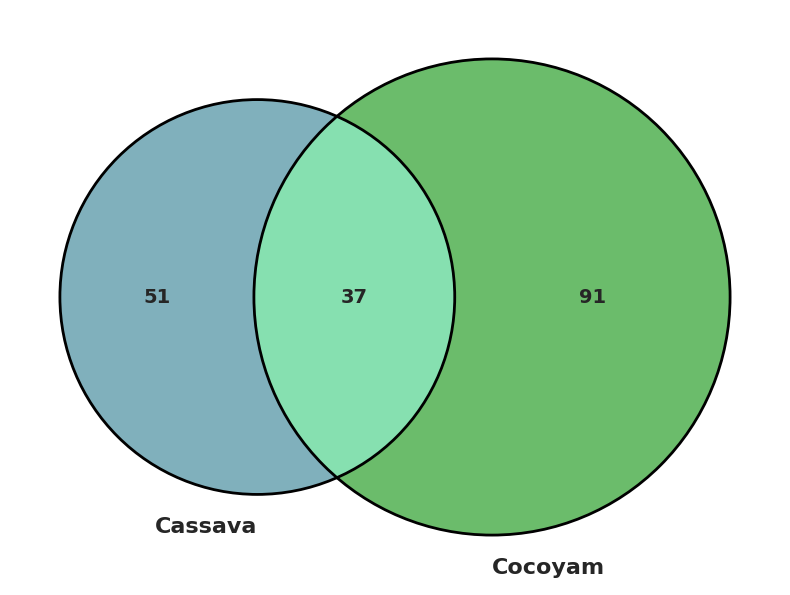

In [6]:
# ── Venn diagram ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8))
tuber_colors = {'Cassava': '#4A8FA0', 'Cocoyam': '#2ca02c'}
venn = venn2(
    [cassava_keys, cocoyam_keys],
    set_labels=('Cassava', 'Cocoyam'),
    set_colors=(tuber_colors['Cassava'], tuber_colors['Cocoyam']),
    alpha=0.7,
    ax=ax
)

# Style the circles
circles = venn2_circles([cassava_keys, cocoyam_keys], linewidth=2, ax=ax)

# Customize label fonts
for text in venn.set_labels:
    if text:
        text.set_fontsize(16)
        text.set_fontweight('bold')

for text in venn.subset_labels:
    if text:
        text.set_fontsize(14)
        text.set_fontweight('bold')

#ax.set_title('Annotation Overlap: InChIKeys (GNPS + High-Conf SIRIUS)', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
fig.savefig(f'{OUTPUT_DIR}/annotation_venn_inchikeys.svg', format='svg', bbox_inches='tight')
print(f"Saved: {OUTPUT_DIR}/annotation_venn_inchikeys.svg")
plt.show()

In [7]:
# ── Breakdown by source ────────────────────────────────────────────────────────
def get_inchikeys_by_source(ms2_df):
    """Get InChIKeys separately by source (SIRIUS = high-confidence only)."""
    gnps_keys = set()
    sirius_keys = set()
    
    if 'gnps_InChIkey2D' in ms2_df.columns:
        gnps = ms2_df['gnps_InChIkey2D'].dropna().astype(str)
        gnps = gnps[gnps.str.len() >= 14]
        gnps_keys = set(gnps.unique())
    
    if 'sirius_InChIkey2D' in ms2_df.columns and 'sirius_high_confidence_sirius' in ms2_df.columns:
        high_conf = ms2_df[ms2_df['sirius_high_confidence_sirius'] == True]
        sirius = high_conf['sirius_InChIkey2D'].dropna().astype(str)
        sirius = sirius[sirius.str.len() >= 14]
        sirius_keys = set(sirius.unique())
    
    return gnps_keys, sirius_keys

def analyze_annotation_agreement(ms2_df, name):
    """
    For features with high-confidence SIRIUS annotations, check agreement with GNPS.
    Returns counts of: agree, disagree, sirius_only, gnps_only
    """
    # Get features with high-confidence SIRIUS annotations
    if 'sirius_high_confidence_sirius' not in ms2_df.columns:
        return None
    
    high_conf = ms2_df[ms2_df['sirius_high_confidence_sirius'] == True].copy()
    
    # Ensure columns exist and clean data
    high_conf['sirius_key'] = high_conf['sirius_InChIkey2D'].fillna('').astype(str)
    high_conf['gnps_key'] = high_conf['gnps_InChIkey2D'].fillna('').astype(str) if 'gnps_InChIkey2D' in high_conf.columns else ''
    
    # Valid keys must be at least 14 chars
    high_conf['sirius_valid'] = high_conf['sirius_key'].str.len() >= 14
    high_conf['gnps_valid'] = high_conf['gnps_key'].str.len() >= 14
    
    # Categories
    both_valid = high_conf['sirius_valid'] & high_conf['gnps_valid']
    sirius_only = high_conf['sirius_valid'] & ~high_conf['gnps_valid']
    
    # For features with both annotations, check agreement
    agree = (both_valid & (high_conf['sirius_key'] == high_conf['gnps_key'])).sum()
    disagree = (both_valid & (high_conf['sirius_key'] != high_conf['gnps_key'])).sum()
    sirius_unique = sirius_only.sum()
    
    print(f"\n=== {name} - Annotation Agreement (High-Conf SIRIUS features) ===")
    print(f"  Total high-confidence SIRIUS features: {len(high_conf):,}")
    print(f"  ├─ Both SIRIUS & GNPS annotated: {both_valid.sum():,}")
    print(f"  │    ├─ Agree (same InChIKey): {agree:,} ({100*agree/both_valid.sum():.1f}%)" if both_valid.sum() > 0 else f"  │    ├─ Agree: {agree:,}")
    print(f"  │    └─ Disagree (different InChIKey): {disagree:,} ({100*disagree/both_valid.sum():.1f}%)" if both_valid.sum() > 0 else f"  │    └─ Disagree: {disagree:,}")
    print(f"  └─ SIRIUS only (no GNPS): {sirius_unique:,}")
    
    return {
        'name': name,
        'total_high_conf': len(high_conf),
        'both_annotated': both_valid.sum(),
        'agree': agree,
        'disagree': disagree,
        'sirius_only': sirius_unique
    }

cass_gnps, cass_sirius = get_inchikeys_by_source(cassava_ms2)
coco_gnps, coco_sirius = get_inchikeys_by_source(cocoyam_ms2)

print("=== Cassava ===")
print(f"  GNPS InChIKeys: {len(cass_gnps):,}")
print(f"  SIRIUS InChIKeys: {len(cass_sirius):,}")
print(f"  Total unique: {len(cass_gnps | cass_sirius):,}")

print("\n=== Cocoyam ===")
print(f"  GNPS InChIKeys: {len(coco_gnps):,}")
print(f"  SIRIUS InChIKeys: {len(coco_sirius):,}")
print(f"  Total unique: {len(coco_gnps | coco_sirius):,}")

print("\n=== Overlap by source ===")
print(f"  GNPS shared: {len(cass_gnps & coco_gnps):,}")
print(f"  SIRIUS shared: {len(cass_sirius & coco_sirius):,}")

# Combined stats for both tubers
all_gnps = cass_gnps | coco_gnps
all_sirius = cass_sirius | coco_sirius
sirius_unique = all_sirius - all_gnps  # SIRIUS only, not in GNPS
gnps_unique = all_gnps - all_sirius    # GNPS only, not in SIRIUS
shared_both = all_gnps & all_sirius    # In both sources

print("\n=== Combined (Both Tubers) ===")
print(f"  SIRIUS unique (not in GNPS): {len(sirius_unique):,}")
print(f"  GNPS unique (not in SIRIUS): {len(gnps_unique):,}")
print(f"  Shared (in both sources): {len(shared_both):,}")
print(f"  Total unique InChIKeys: {len(all_gnps | all_sirius):,}")

# Analyze agreement at feature level
cass_agreement = analyze_annotation_agreement(cassava_ms2, 'Cassava')
coco_agreement = analyze_annotation_agreement(cocoyam_ms2, 'Cocoyam')

=== Cassava ===
  GNPS InChIKeys: 6
  SIRIUS InChIKeys: 84
  Total unique: 88

=== Cocoyam ===
  GNPS InChIKeys: 23
  SIRIUS InChIKeys: 111
  Total unique: 128

=== Overlap by source ===
  GNPS shared: 3
  SIRIUS shared: 35

=== Combined (Both Tubers) ===
  SIRIUS unique (not in GNPS): 153
  GNPS unique (not in SIRIUS): 19
  Shared (in both sources): 7
  Total unique InChIKeys: 179

=== Cassava - Annotation Agreement (High-Conf SIRIUS features) ===
  Total high-confidence SIRIUS features: 93
  ├─ Both SIRIUS & GNPS annotated: 3
  │    ├─ Agree (same InChIKey): 2 (66.7%)
  │    └─ Disagree (different InChIKey): 1 (33.3%)
  └─ SIRIUS only (no GNPS): 90

=== Cocoyam - Annotation Agreement (High-Conf SIRIUS features) ===
  Total high-confidence SIRIUS features: 125
  ├─ Both SIRIUS & GNPS annotated: 9
  │    ├─ Agree (same InChIKey): 5 (55.6%)
  │    └─ Disagree (different InChIKey): 4 (44.4%)
  └─ SIRIUS only (no GNPS): 116


In [8]:
# ── Database configuration ─────────────────────────────────────────────────────
SELECTED_DBS = [
    'PUBCHEM', 'CHEBI', 'LIPIDMAPS', 'HMDB',
    'FooDB', 'COCONUT', 'NORMAN', 'DSSTox',
    'cassava1st', 'cocoyam1step', 'SUPERNATURAL'
]

DB_LABELS = {
    'PUBCHEM'        : 'PubChem',
    'CHEBI'          : 'ChEBI',
    'LIPIDMAPS'      : 'LipidMaps',
    'HMDB'           : 'HMDB',
    'FooDB'          : 'FooDB',
    'COCONUT'        : 'COCONUT',
    'NORMAN'         : 'NORMAN',
    'DSSTox'         : 'DSSTox',
    'cassava1st'     : 'BioTransformer',
    'SUPERNATURAL'   : 'SuperNatural',
    'cocoyam1step'  : 'BioTransformer',
}

print("Selected databases:")
for db in SELECTED_DBS:
    print(f"  - {db} → {DB_LABELS[db]}")

Selected databases:
  - PUBCHEM → PubChem
  - CHEBI → ChEBI
  - LIPIDMAPS → LipidMaps
  - HMDB → HMDB
  - FooDB → FooDB
  - COCONUT → COCONUT
  - NORMAN → NORMAN
  - DSSTox → DSSTox
  - cassava1st → BioTransformer
  - cocoyam1step → BioTransformer
  - SUPERNATURAL → SuperNatural



=== Creating combined UpSet plot ===
Cassava features with DB matches: 93
Cocoyam features with DB matches: 125
Total combined: 218
Saved: ../figures/separate_treatment/combined_upset_database.svg


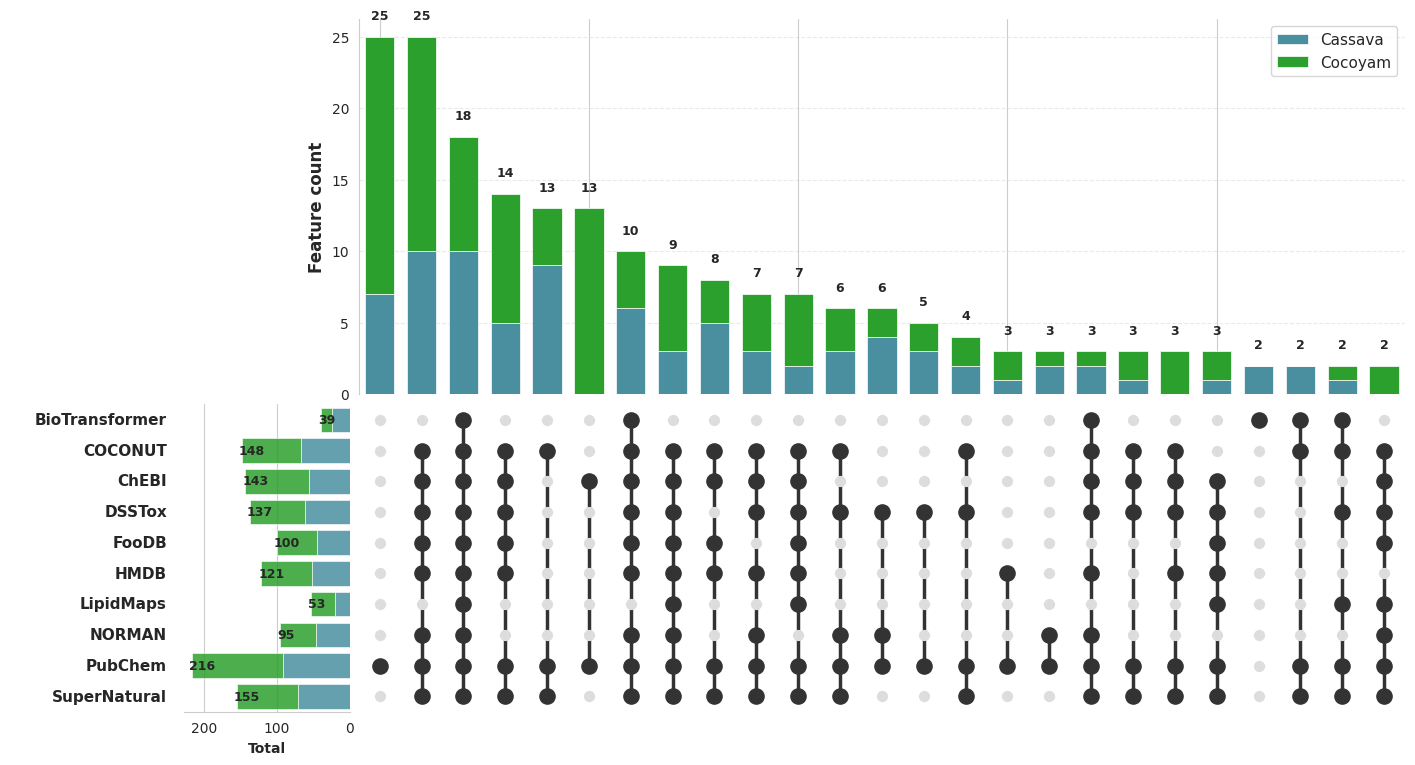

In [9]:
# ── Combined UpSet plot for both tubers ────────────────────────────────────────
def create_combined_upset_plot(cassava_ms2_df, cocoyam_ms2_df, output_dir):
    """
    Create combined UpSet plot with stacked bars showing Cassava vs Cocoyam.
    """
    
    def get_memberships_with_tuber(ms2_df, tuber_name):
        """Extract database memberships with tuber label."""
        if 'sirius_high_confidence_sirius' not in ms2_df.columns:
            return []
        
        high_conf = ms2_df[ms2_df['sirius_high_confidence_sirius'] == True].copy()
        
        records = []
        for _, row in high_conf.iterrows():
            feature_dbs = set()
            if pd.notna(row.get('sirius_links')):
                parts = [p.strip() for p in row['sirius_links'].split(';')]
                for part in parts:
                    db_name = part.split(':')[0].strip()
                    if db_name in SELECTED_DBS:
                        feature_dbs.add(DB_LABELS[db_name])
            if feature_dbs:
                records.append({
                    'databases': tuple(sorted(feature_dbs)),
                    'tuber': tuber_name
                })
        return records
    
    # Get memberships from both tubers
    cassava_records = get_memberships_with_tuber(cassava_ms2_df, 'Cassava')
    cocoyam_records = get_memberships_with_tuber(cocoyam_ms2_df, 'Cocoyam')
    
    all_records = cassava_records + cocoyam_records
    
    if not all_records:
        print("No database matches found in either tuber")
        return
    
    print(f"Cassava features with DB matches: {len(cassava_records)}")
    print(f"Cocoyam features with DB matches: {len(cocoyam_records)}")
    print(f"Total combined: {len(all_records)}")
    
    # Create DataFrame
    df = pd.DataFrame(all_records)
    
    # Get all unique databases
    all_dbs = set()
    for dbs in df['databases']:
        all_dbs.update(dbs)
    all_dbs = sorted(all_dbs)
    
    # Create boolean columns for each database
    for db in all_dbs:
        df[db] = df['databases'].apply(lambda x: db in x)
    
    # Set multi-index for grouping
    df_indexed = df.set_index(all_dbs)
    
    # Count by intersection and tuber
    counts = df_indexed.groupby(level=all_dbs)['tuber'].value_counts().unstack(fill_value=0)
    
    for tuber in ['Cassava', 'Cocoyam']:
        if tuber not in counts.columns:
            counts[tuber] = 0
    
    counts['total'] = counts['Cassava'] + counts['Cocoyam']
    counts = counts.sort_values('total', ascending=False)
    counts = counts[counts['total'] >= 2]
    
    if counts.empty:
        print("No intersections with ≥2 features")
        return
    
    # Calculate totals per database AND per tuber
    db_totals = {db: df[db].sum() for db in all_dbs}
    db_totals_by_tuber = {}
    for db in all_dbs:
        db_totals_by_tuber[db] = {
            'Cassava': df[(df[db] == True) & (df['tuber'] == 'Cassava')].shape[0],
            'Cocoyam': df[(df[db] == True) & (df['tuber'] == 'Cocoyam')].shape[0]
        }
    
    # Create figure with 3 columns: labels, totals, main plot
    fig = plt.figure(figsize=(18, 9))
    gs = fig.add_gridspec(2, 3, width_ratios=[0.12, 0.12, 0.76], height_ratios=[0.55, 0.45],
                          hspace=0.03, wspace=0.02)
    
    ax_bars = fig.add_subplot(gs[0, 2])        # Stacked bars (top right)
    ax_matrix = fig.add_subplot(gs[1, 2])      # Matrix (bottom right)
    ax_totals = fig.add_subplot(gs[1, 1])      # Totals bars (bottom middle)
    ax_labels = fig.add_subplot(gs[1, 0])      # Database labels (bottom left)
    ax_empty1 = fig.add_subplot(gs[0, 0])
    ax_empty2 = fig.add_subplot(gs[0, 1])
    ax_empty1.axis('off')
    ax_empty2.axis('off')
    
    n_intersections = min(25, len(counts))
    plot_data = counts.head(n_intersections)
    
    # Colors matching PCA (Control colors for each tuber)
    tuber_colors = {'Cassava': '#4A8FA0', 'Cocoyam': '#2ca02c'}
    
    # Stacked bars
    x = np.arange(n_intersections)
    width = 0.7
    
    ax_bars.bar(x, plot_data['Cassava'], width, label='Cassava', 
                color=tuber_colors['Cassava'], edgecolor='white', linewidth=0.5)
    ax_bars.bar(x, plot_data['Cocoyam'], width, bottom=plot_data['Cassava'],
                label='Cocoyam', color=tuber_colors['Cocoyam'], edgecolor='white', linewidth=0.5)
    
    # Count labels
    for i, (cass, coco) in enumerate(zip(plot_data['Cassava'], plot_data['Cocoyam'])):
        total = cass + coco
        ax_bars.text(i, total + 1, str(total), ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax_bars.set_ylabel('Feature count', fontsize=12, fontweight='bold')
    ax_bars.set_xlim(-0.5, n_intersections - 0.5)
    ax_bars.legend(loc='upper right', fontsize=11, frameon=True, fancybox=True)
    ax_bars.spines[['top', 'right', 'bottom']].set_visible(False)
    ax_bars.tick_params(bottom=False, labelbottom=False)
    ax_bars.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax_bars.set_axisbelow(True)
    
    # Matrix
    for i, (idx, _) in enumerate(plot_data.iterrows()):
        idx_tuple = idx if isinstance(idx, tuple) else (idx,)
        for j, db in enumerate(all_dbs):
            if idx_tuple[j]:
                ax_matrix.scatter(i, j, s=120, c='#333333', zorder=3)
            else:
                ax_matrix.scatter(i, j, s=50, c='#DDDDDD', zorder=2)
        
        active = [j for j, db in enumerate(all_dbs) if idx_tuple[j]]
        if len(active) > 1:
            ax_matrix.plot([i, i], [min(active), max(active)], c='#333333', linewidth=2.5, zorder=1)
    
    ax_matrix.set_yticks([])
    ax_matrix.set_xlim(-0.5, n_intersections - 0.5)
    ax_matrix.set_ylim(-0.5, len(all_dbs) - 0.5)
    ax_matrix.set_xticks([])
    ax_matrix.invert_yaxis()
    ax_matrix.spines[['top', 'right', 'bottom', 'left']].set_visible(False)
    
    # Database labels (left side)
    ax_labels.set_ylim(-0.5, len(all_dbs) - 0.5)
    ax_labels.set_xlim(0, 1)
    ax_labels.invert_yaxis()
    for j, db in enumerate(all_dbs):
        ax_labels.text(0.95, j, db, ha='right', va='center', fontsize=11, fontweight='bold')
    ax_labels.axis('off')
    
    # Totals (horizontal stacked bars by tuber)
    y_pos = np.arange(len(all_dbs))
    db_counts_list = [db_totals[db] for db in all_dbs]
    cassava_counts = [db_totals_by_tuber[db]['Cassava'] for db in all_dbs]
    cocoyam_counts = [db_totals_by_tuber[db]['Cocoyam'] for db in all_dbs]
    
    ax_totals.barh(y_pos, cassava_counts, color=tuber_colors['Cassava'], alpha=0.85, edgecolor='white', linewidth=0.5)
    ax_totals.barh(y_pos, cocoyam_counts, left=cassava_counts, color=tuber_colors['Cocoyam'], alpha=0.85, edgecolor='white', linewidth=0.5)
    ax_totals.set_ylim(-0.5, len(all_dbs) - 0.5)
    ax_totals.set_yticks([])
    ax_totals.invert_xaxis()
    ax_totals.invert_yaxis()
    ax_totals.spines[['top', 'right', 'left']].set_visible(False)
    ax_totals.set_xlabel('Total', fontsize=10, fontweight='bold')
    
    # Add count labels on totals bars
    max_count = max(db_counts_list)
    for i, count in enumerate(db_counts_list):
        ax_totals.text(count + max_count * 0.02, i, str(count), ha='left', va='center', fontsize=9, fontweight='bold')
    
    n_total = len(all_records)
    
    plt.savefig(f'{output_dir}/combined_upset_database.svg', format='svg', bbox_inches='tight')
    print(f"Saved: {output_dir}/combined_upset_database.svg")
    plt.show()

# Create combined plot
print("\n=== Creating combined UpSet plot ===")
create_combined_upset_plot(cassava_ms2, cocoyam_ms2, OUTPUT_DIR)

In [10]:
# ── Build significant features table with MS2 annotations ──────────────────────
# Include both high-confidence SIRIUS and GNPS annotations
from scipy import stats

# Column definitions
csf1_cols = [f"CSF_1_rep_{r}_norm_log2" for r in (1,2,3)]
csf2_cols = [f"CSF_2_rep_{r}_norm_log2" for r in (1,2,3)]
cyf1_cols = [f"CYF_1_rep_{r}_norm_log2" for r in (1,2,3)]
cyf2_cols = [f"CYF_2_rep_{r}_norm_log2" for r in (1,2,3)]

# Config
tuber_config = {
    'Cassava': {
        'merged': cassava_merged,
        'quant' : cassava_quant,
        'ctrl'  : csf1_cols,
        'ferm'  : csf2_cols,
    },
    'Cocoyam': {
        'merged': cocoyam_merged,
        'quant' : cocoyam_quant,
        'ctrl'  : cyf1_cols,
        'ferm'  : cyf2_cols,
    },
}

all_records = []
for tuber, cfg in tuber_config.items():
    merged = cfg['merged']
    quant = cfg['quant']
    
    # Get features with either high-confidence SIRIUS OR valid GNPS annotation
    has_sirius = merged['sirius_high_confidence_sirius'] == True
    has_gnps = merged['gnps_InChIkey2D'].notna() & (merged['gnps_InChIkey2D'].str.len() >= 14)
    annotated = merged[has_sirius | has_gnps].copy()
    
    for _, row in annotated.iterrows():
        fid = row['id']
        
        # Get intensity values from quant data
        quant_row = quant[quant['id'] == fid]
        if quant_row.empty:
            continue
        quant_row = quant_row.iloc[0]
        
        ctrl = pd.to_numeric(quant_row[cfg['ctrl']], errors='coerce').values
        ferm = pd.to_numeric(quant_row[cfg['ferm']], errors='coerce').values
        
        if np.isfinite(ctrl).sum() < 2 or np.isfinite(ferm).sum() < 2:
            continue
        
        # Calculate stats
        _, pval = stats.ttest_ind(ctrl, ferm, equal_var=False, nan_policy='omit')
        log2fc = np.nanmean(ferm) - np.nanmean(ctrl)
        
        # Determine significance and direction
        is_sig = (pval < FDR_CUTOFF) and (abs(log2fc) > LOG2FC_THRESHOLD)
        direction = 'up' if log2fc > 0 else 'down'
        
        # Get InChIKey - prefer SIRIUS high-conf, fall back to GNPS
        sirius_key = row.get('sirius_InChIkey2D', '')
        gnps_key = row.get('gnps_InChIkey2D', '')
        sirius_valid = pd.notna(sirius_key) and len(str(sirius_key)) >= 14 and row.get('sirius_high_confidence_sirius', False)
        gnps_valid = pd.notna(gnps_key) and len(str(gnps_key)) >= 14
        
        # Unified InChIKey: SIRIUS (if high-conf) > GNPS
        if sirius_valid:
            unified_inchikey = str(sirius_key)
            annotation_source = 'SIRIUS'
        elif gnps_valid:
            unified_inchikey = str(gnps_key)
            annotation_source = 'GNPS'
        else:
            unified_inchikey = ''
            annotation_source = 'Unknown'
        
        # Get compound name - prefer SIRIUS, fall back to GNPS
        compound_name = row.get('sirius_name', '')
        if pd.isna(compound_name) or compound_name == '':
            compound_name = row.get('gnps_Compound_Name', '')
        
        record = {
            'tuber'           : tuber,
            'id'              : fid,
            'log2FC'          : round(log2fc, 3),
            'pvalue'          : round(pval, 6),
            'significant'     : is_sig,
            'direction'       : direction if is_sig else 'ns',
            'ctrl_mean'       : round(np.nanmean(ctrl), 3),
            'ferm_mean'       : round(np.nanmean(ferm), 3),
            'unified_inchikey': unified_inchikey,
            'annotation_source': annotation_source,
            'compound_name'   : compound_name,
        }
        
        # Add annotation columns
        for col in ['sirius_name', 'sirius_high_confidence_sirius',
                    'sirius_NPC#pathway', 'sirius_NPC#class', 'sirius_NPC#superclass',
                    'sirius_ClassyFire#superclass', 'sirius_ClassyFire#class',
                    'sirius_links', 'gnps_Compound_Name', 'gnps_InChIkey2D', 'sirius_InChIkey2D']:
            record[col] = row.get(col, '')
        
        all_records.append(record)

sig_features_df = pd.DataFrame(all_records)

# Summary
print("=== Annotated Features Summary (SIRIUS high-conf + GNPS) ===")
print(f"Total annotated features: {len(sig_features_df):,}")
print(f"  - SIRIUS high-conf: {(sig_features_df['annotation_source'] == 'SIRIUS').sum():,}")
print(f"  - GNPS only: {(sig_features_df['annotation_source'] == 'GNPS').sum():,}")
print(f"Significant (p<{FDR_CUTOFF}, |log2FC|>{LOG2FC_THRESHOLD}): {sig_features_df['significant'].sum():,}")
print()

for tuber in ['Cassava', 'Cocoyam']:
    df_t = sig_features_df[sig_features_df['tuber'] == tuber]
    sig_t = df_t[df_t['significant'] == True]
    print(f"{tuber}:")
    print(f"  Total: {len(df_t):,}")
    print(f"  Significant: {len(sig_t):,}")
    print(f"    Up in fermented: {(sig_t['direction'] == 'up').sum():,}")
    print(f"    Down in fermented: {(sig_t['direction'] == 'down').sum():,}")
    print()

# Count unique InChIKeys
unique_keys = sig_features_df[sig_features_df['unified_inchikey'] != '']['unified_inchikey'].nunique()
print(f"Unique InChIKeys across both tubers: {unique_keys:,}")

# Save to CSV
csv_path = f'{OUTPUT_DIR}/significant_features_annotated.csv'
sig_features_df.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path}")

=== Annotated Features Summary (SIRIUS high-conf + GNPS) ===
Total annotated features: 235
  - SIRIUS high-conf: 217
  - GNPS only: 18
Significant (p<0.05, |log2FC|>1.0): 75

Cassava:
  Total: 95
  Significant: 47
    Up in fermented: 3
    Down in fermented: 44

Cocoyam:
  Total: 140
  Significant: 28
    Up in fermented: 14
    Down in fermented: 14

Unique InChIKeys across both tubers: 176

Saved: ../figures/separate_treatment/significant_features_annotated.csv


In [11]:
# ── Select interesting molecules for bar plot ──────────────────────────────────
# MANUAL SELECTION: specify feature IDs for each tuber (up_id, down_id)
# Set to (up_id, down_id) tuple, or None to auto-select

MANUAL_SELECTION = {
    'Cassava': (405, 1996),   # (up_id, down_id) - e.g., (574, 582) or (None, None) for auto
    'Cocoyam': (667, 325),   # (up_id, down_id) - e.g., (427, 3662) or (None, None) for auto
}

selected_features = []

for tuber in ['Cassava', 'Cocoyam']:
    df_t = sig_features_df[sig_features_df['tuber'] == tuber]
    sig_t = df_t[df_t['significant'] == True]
    
    manual_ids = MANUAL_SELECTION.get(tuber, (None, None))
    if manual_ids is None:
        manual_ids = (None, None)
    
    up_id, down_id = manual_ids
    
    # UP feature
    if up_id is not None:
        row = df_t[df_t['id'] == int(up_id)]
        if row.empty:
            print(f"⚠️  Warning: UP ID {up_id} not found for {tuber}, auto-selecting")
            up_id = None
        else:
            row = row.iloc[0]
            name = row['compound_name'] if pd.notna(row['compound_name']) and row['compound_name'] != '' else f"Feature {row['id']}"
            selected_features.append({
                'id': row['id'],
                'name': name,
                'tuber': tuber,
                'direction': 'up' if row['log2FC'] > 0 else 'down',
                'log2FC': row['log2FC'],
                'source': row['annotation_source'],
            })
    
    if up_id is None:
        # Auto-select top UP
        up_cands = sig_t[sig_t['log2FC'] > 0]
        if not up_cands.empty:
            top_up = up_cands.loc[up_cands['log2FC'].idxmax()]
            name = top_up['compound_name'] if pd.notna(top_up['compound_name']) and top_up['compound_name'] != '' else f"Feature {top_up['id']}"
            selected_features.append({
                'id': top_up['id'],
                'name': name,
                'tuber': tuber,
                'direction': 'up',
                'log2FC': top_up['log2FC'],
                'source': top_up['annotation_source'],
            })
    
    # DOWN feature
    if down_id is not None:
        row = df_t[df_t['id'] == int(down_id)]
        if row.empty:
            print(f"⚠️  Warning: DOWN ID {down_id} not found for {tuber}, auto-selecting")
            down_id = None
        else:
            row = row.iloc[0]
            name = row['compound_name'] if pd.notna(row['compound_name']) and row['compound_name'] != '' else f"Feature {row['id']}"
            selected_features.append({
                'id': row['id'],
                'name': name,
                'tuber': tuber,
                'direction': 'down' if row['log2FC'] < 0 else 'up',
                'log2FC': row['log2FC'],
                'source': row['annotation_source'],
            })
    
    if down_id is None:
        # Auto-select top DOWN
        down_cands = sig_t[sig_t['log2FC'] < 0]
        if not down_cands.empty:
            top_down = down_cands.loc[down_cands['log2FC'].idxmin()]
            name = top_down['compound_name'] if pd.notna(top_down['compound_name']) and top_down['compound_name'] != '' else f"Feature {top_down['id']}"
            selected_features.append({
                'id': top_down['id'],
                'name': name,
                'tuber': tuber,
                'direction': 'down',
                'log2FC': top_down['log2FC'],
                'source': top_down['annotation_source'],
            })

print("=== Selected features for bar plot ===")
for feat in selected_features:
    print(f"  {feat['tuber']} {feat['direction']}: {feat['name']} (id={feat['id']}, log2FC={feat['log2FC']:.2f}, source={feat['source']})")

⚠️  Warning: UP ID 405 not found for Cassava, auto-selecting
=== Selected features for bar plot ===
  Cassava up: Methylthioadenosine (id=574, log2FC=9.36, source=SIRIUS)
  Cassava down: Gingerglycolipid B (id=1996, log2FC=-4.83, source=SIRIUS)
  Cocoyam up: Feruloylagmatine (id=667, log2FC=3.21, source=SIRIUS)
  Cocoyam down: Xanthin (id=325, log2FC=-5.92, source=SIRIUS)


/tmp/ipykernel_304047/3975457220.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: ../figures/separate_treatment/example_compounds_barplot.svg


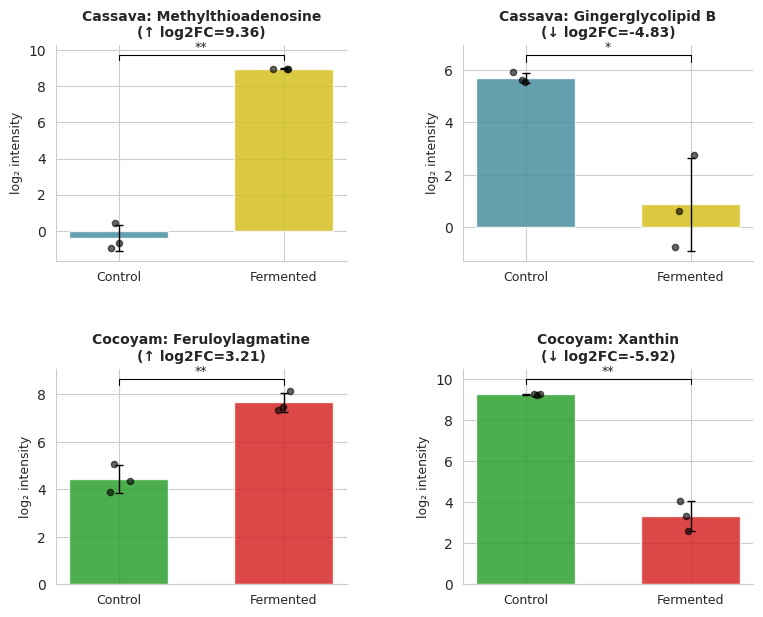

In [12]:
# ── Bar Plot of Selected Compounds ─────────────────────────────────────────────
from scipy import stats

# Group definitions for plotting - use the tuber-specific columns
groups_cassava = {
    'Control'  : csf1_cols,
    'Fermented': csf2_cols,
}
groups_cocoyam = {
    'Control'  : cyf1_cols,
    'Fermented': cyf2_cols,
}

tuber_plot_config = {
    'Cassava': {
        'groups': groups_cassava,
        'colors': {'Control': '#4A8FA0', 'Fermented': '#D4C020'},
        'quant' : cassava_quant,
    },
    'Cocoyam': {
        'groups': groups_cocoyam,
        'colors': {'Control': '#2ca02c', 'Fermented': '#d62728'},
        'quant' : cocoyam_quant,
    },
}

# Order features by tuber
ordered_features = [f for f in selected_features if f['tuber'] == 'Cassava'] + \
                   [f for f in selected_features if f['tuber'] == 'Cocoyam']

n_features = len(ordered_features)
if n_features == 0:
    print("No features selected!")
else:
    # Dynamic grid: 1 row for 1-2 features, 2 rows for 3-4 features
    if n_features <= 2:
        fig, axes = plt.subplots(1, n_features, figsize=(4.5 * n_features, 4))
        if n_features == 1:
            axes = [axes]
    else:
        nrows = (n_features + 1) // 2
        ncols = 2
        fig, axes = plt.subplots(nrows, ncols, figsize=(9, 3.5 * nrows), 
                                 gridspec_kw={'hspace': 0.5, 'wspace': 0.4})
        axes = axes.flatten()

    for ax_idx, feat in enumerate(ordered_features):
        ax = axes[ax_idx]
        tuber = feat['tuber']
        cfg = tuber_plot_config[tuber]
        quant = cfg['quant']
        
        # Get intensity values
        quant_row = quant[quant['id'] == feat['id']]
        if quant_row.empty:
            ax.set_visible(False)
            continue
        quant_row = quant_row.iloc[0]
        
        group_vals = {}
        for gname, cols in cfg['groups'].items():
            vals = pd.to_numeric(quant_row[cols], errors='coerce').values
            group_vals[gname] = vals
        
        group_names = list(cfg['groups'].keys())
        x_positions = np.arange(len(group_names))
        
        # Calculate means and SEMs
        means = [np.nanmean(v) for v in group_vals.values()]
        sems = [np.nanstd(v, ddof=1) / np.sqrt(np.sum(np.isfinite(v))) for v in group_vals.values()]
        sds = [np.nanstd(v, ddof=1) for v in group_vals.values()]
        
        # Bar plot
        bars = ax.bar(x_positions, means,
                      color=[cfg['colors'][g] for g in group_names],
                      width=0.6, alpha=0.85, zorder=2)
        
        # Error bars
        ax.errorbar(x_positions, means, yerr=sds,
                    fmt='none', color='black',
                    capsize=3, linewidth=1, zorder=3)
        
        # Jittered individual points
        for xi, (gname, vals) in enumerate(group_vals.items()):
            jitter = np.random.uniform(-0.1, 0.1, size=len(vals))
            ax.scatter(np.full(len(vals), xi) + jitter, vals,
                       color='black', s=20, zorder=4, alpha=0.6)
        
        # Significance bracket
        ctrl_vals = group_vals['Control']
        ferm_vals = group_vals['Fermented']
        _, pval = stats.ttest_ind(ctrl_vals, ferm_vals, equal_var=False, nan_policy='omit')
        
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        
        y_max = max(means[0] + sems[0], means[1] + sems[1])
        bracket_y = y_max + 0.5
        ax.plot([0, 0, 1, 1],
                [bracket_y, bracket_y + 0.25, bracket_y + 0.25, bracket_y],
                color='black', linewidth=0.8)
        ax.text(0.5, bracket_y + 0.3, sig, ha='center', va='bottom', fontsize=9)
        
        ax.set_xticks(x_positions)
        ax.set_xticklabels(group_names, fontsize=9)
        ax.set_ylabel('log₂ intensity', fontsize=9)
        
        # Title with tuber, direction arrow
        arrow = '↑' if feat['direction'] == 'up' else '↓'
        ax.set_title(f"{tuber}: {feat['name']}\n({arrow} log2FC={feat['log2FC']:.2f})", fontsize=10, fontweight='bold')
        ax.spines[['top', 'right']].set_visible(False)

    # Hide extra axes if any
    for j in range(n_features, len(axes)):
        axes[j].set_visible(False)

    fig.tight_layout()
    fig.savefig(f'{OUTPUT_DIR}/example_compounds_barplot.svg', format='svg', bbox_inches='tight')
    fig.savefig(f'{OUTPUT_DIR}/example_compounds_barplot.png', dpi=300, bbox_inches='tight')
    print(f"Saved: {OUTPUT_DIR}/example_compounds_barplot.svg")
    plt.show()

PE(18:1/18:1); [M+H]+ C41H79N1O8P1
2-[2-[(2-amino-4-methylpentanoyl)amino]propanoylamino]-3-(1H-indol-3-yl)propanoic acid


/tmp/ipykernel_304047/567289066.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Saved: ../figures/separate_treatment/cocoyam_barplot_4460_1171.svg/.png


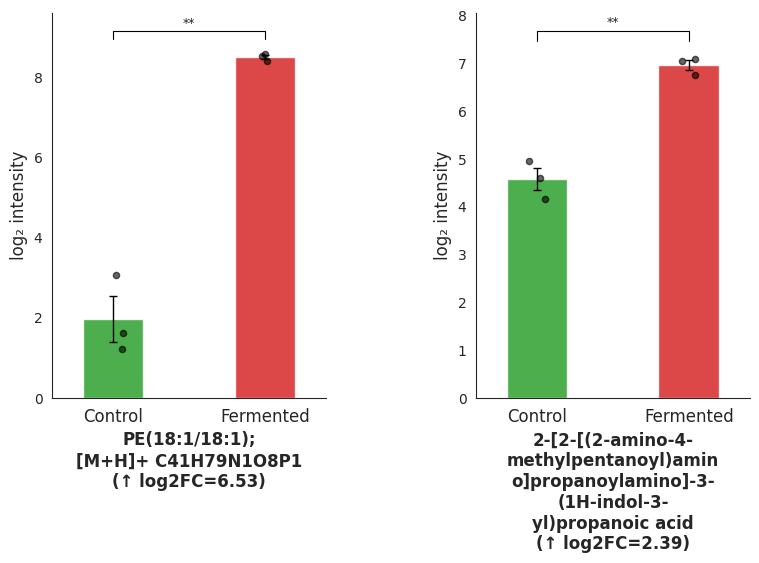

In [13]:
# ── Side-by-side bar plots for two metabolites from a single tuber ─────────────────
# PARAMETERS: set TUBER and FEATURE_IDS before running
# TUBER        : 'cassava' or 'cocoyam'
# FEATURE_IDS  : tuple of two feature IDs (int) from the corresponding database

TUBER       = 'cocoyam'       # <-- change to 'cocoyam' as needed
FEATURE_IDS = (4460, 1171)     # <-- two feature IDs to compare
sns.set_style('white')
import textwrap
from scipy import stats

# ── Config driven by TUBER parameter ─────────────────────────────────────────────
_cfg = {
    'cassava': {
        'quant'    : cassava_quant,
        'merged'   : cassava_merged,
        'ctrl_cols': [f"CSF_1_rep_{r}_norm_log2" for r in (1, 2, 3)],
        'ferm_cols': [f"CSF_2_rep_{r}_norm_log2" for r in (1, 2, 3)],
        'colors'   : {'Control': '#4A8FA0', 'Fermented': '#D4C020'},
        'label'    : 'Cassava',
    },
    'cocoyam': {
        'quant'    : cocoyam_quant,
        'merged'   : cocoyam_merged,
        'ctrl_cols': [f"CYF_1_rep_{r}_norm_log2" for r in (1, 2, 3)],
        'ferm_cols': [f"CYF_2_rep_{r}_norm_log2" for r in (1, 2, 3)],
        'colors'   : {'Control': '#2ca02c', 'Fermented': '#d62728'},
        'label'    : 'Cocoyam',
    },
}

cfg = _cfg[TUBER.lower()]


def _get_compound_name(feature_id, merged_df):
    row = merged_df[merged_df['id'] == feature_id]
    if row.empty:
        return f"Feature {feature_id}"
    row = row.iloc[0]
    for col in ('sirius_name', 'gnps_Compound_Name', 'compound_name'):
        if col in row.index and pd.notna(row[col]) and str(row[col]).strip():
            return str(row[col]).strip()
    return f"Feature {feature_id}"


def _plot_barplot(ax, feature_id, cfg):
    quant_row = cfg['quant'][cfg['quant']['id'] == feature_id]
    if quant_row.empty:
        ax.set_visible(False)
        print(f"Feature {feature_id} not found in {cfg['label']} quant table.")
        return

    quant_row = quant_row.iloc[0]
    groups = {
        'Control'  : pd.to_numeric(quant_row[cfg['ctrl_cols']], errors='coerce').values,
        'Fermented': pd.to_numeric(quant_row[cfg['ferm_cols']], errors='coerce').values,
    }

    group_names = list(groups.keys())
    x_pos  = np.array([0.0, 1.5])
    means  = [np.nanmean(v) for v in groups.values()]
    sems   = [np.nanstd(v, ddof=1) / np.sqrt(np.sum(np.isfinite(v))) for v in groups.values()]

    ax.bar(x_pos, means,
           color=[cfg['colors'][g] for g in group_names],
           width=0.6, alpha=0.85, zorder=2)
    ax.errorbar(x_pos, means, yerr=sems,
                fmt='none', color='black', capsize=3, linewidth=1, zorder=3)

    for xi, (gname, vals) in enumerate(groups.items()):
        jitter = np.random.uniform(-0.1, 0.1, size=len(vals))
        ax.scatter(np.full(len(vals), x_pos[xi]) + jitter, vals,
                   color='black', s=20, zorder=4, alpha=0.6)

    # Significance bracket
    _, pval = stats.ttest_ind(groups['Control'], groups['Fermented'],
                               equal_var=False, nan_policy='omit')
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    y_max = max(m + s for m, s in zip(means, sems))
    bracket_y = y_max + 0.4
    ax.plot([x_pos[0], x_pos[0], x_pos[1], x_pos[1]],
            [bracket_y, bracket_y + 0.2, bracket_y + 0.2, bracket_y],
            color='black', linewidth=0.8)
    ax.text(np.mean(x_pos), bracket_y + 0.25, sig, ha='center', va='bottom', fontsize=9)

    # Wrapped compound name as x-axis label below the plot
    compound_name = _get_compound_name(feature_id, cfg['merged'])
    wrapped_name  = '\n'.join(textwrap.wrap(compound_name, width=20))
    print(compound_name)

    log2fc_row = cfg['merged'][cfg['merged']['id'] == feature_id]
    if not log2fc_row.empty and 'log2FC' in log2fc_row.columns:
        fc = log2fc_row.iloc[0]['log2FC']
        arrow = '↑' if fc > 0 else '↓'
        wrapped_name += f"\n({arrow} log2FC={fc:.2f})"

    ax.set_xlabel(wrapped_name, fontsize=12, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(group_names, fontsize=12)
    ax.set_xlim(-0.6, 2.1)
    ax.set_ylabel('log₂ intensity', fontsize=12)
    ax.spines[['top', 'right']].set_visible(False)


# ── Plot ───────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(9, 5), sharey=False,
                          gridspec_kw={'wspace': 0.55})

for ax, fid in zip(axes, FEATURE_IDS):
    _plot_barplot(ax, fid, cfg)

fig.tight_layout()

out_stem = f"{OUTPUT_DIR}/{TUBER.lower()}_barplot_{'_'.join(str(i) for i in FEATURE_IDS)}"
fig.savefig(f"{out_stem}.svg", format='svg', bbox_inches='tight')
fig.savefig(f"{out_stem}.png", dpi=300, bbox_inches='tight')
print(f"Saved: {out_stem}.svg/.png")
plt.show()



✓ SAVED: ../figures/separate_treatment/figure3_standardized.svg
✓ SAVED: ../figures/separate_treatment/figure3_standardized.png


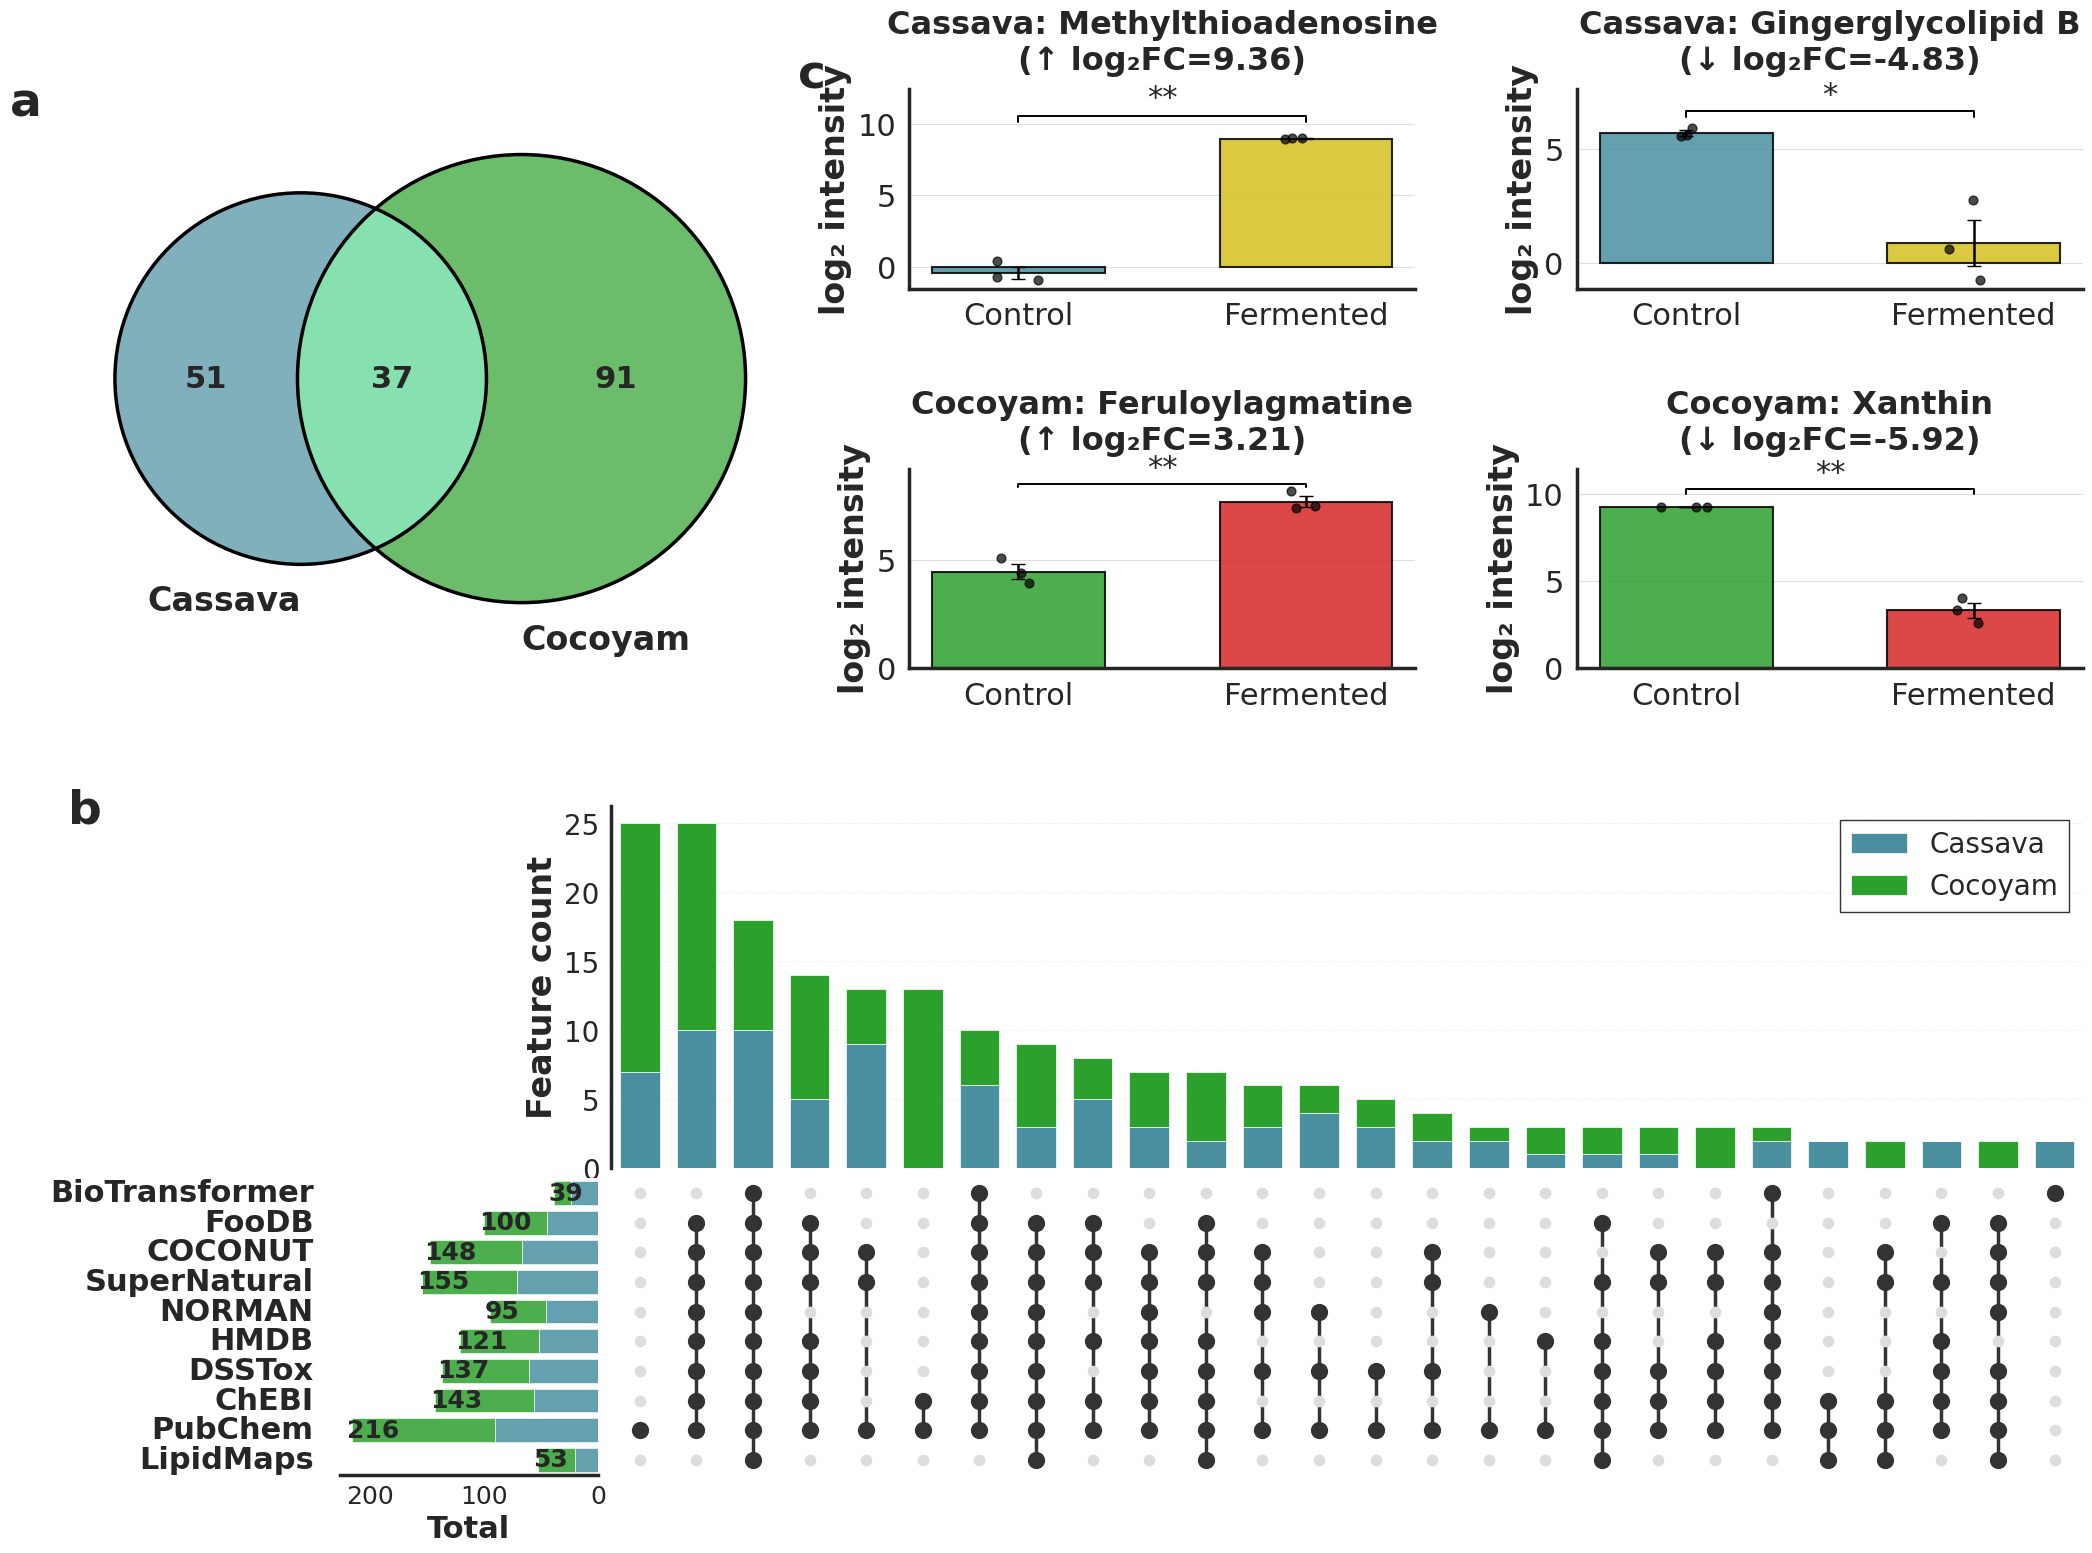

In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 3: STANDARDIZED & HARMONIZED VERSION
# Layout: a = Venn (top-left), c = compounds (top-right 2×2), b = UpSet (bottom)
# Matching publication-ready style from Figure 1 & 2
# ═══════════════════════════════════════════════════════════════════════════

from scipy import stats
import matplotlib.gridspec as mgridspec

# ─── STYLING PARAMETERS ──────────────────────────────────────────────────
LABEL_FONTSIZE       = 24
TICK_FONTSIZE        = 22
LEGEND_FONTSIZE      = 20
PANEL_LABEL_FONTSIZE = 34
SPINE_WIDTH          = 2.5
GRID_ALPHA           = 0.25
BAR_ALPHA            = 0.85

# Colors
tuber_colors   = {'Cassava': '#4A8FA0', 'Cocoyam': '#2ca02c'}
cassava_colors = {'Control': '#4A8FA0', 'Fermented': '#D4C020'}
cocoyam_colors = {'Control': '#2ca02c', 'Fermented': '#d62728'}

# ─── BUILD UPSET DATA ─────────────────────────────────────────────────────
def _get_memberships(ms2_df, tuber_name):
    if 'sirius_high_confidence_sirius' not in ms2_df.columns:
        return []
    high_conf = ms2_df[ms2_df['sirius_high_confidence_sirius'] == True].copy()
    records = []
    for _, row in high_conf.iterrows():
        feature_dbs = set()
        if pd.notna(row.get('sirius_links')):
            for part in [p.strip() for p in row['sirius_links'].split(';')]:
                db_name = part.split(':')[0].strip()
                if db_name in SELECTED_DBS:
                    feature_dbs.add(DB_LABELS[db_name])
        if feature_dbs:
            records.append({'databases': tuple(sorted(feature_dbs)), 'tuber': tuber_name})
    return records

all_upset_records = _get_memberships(cassava_ms2, 'Cassava') + _get_memberships(cocoyam_ms2, 'Cocoyam')
df_upset = pd.DataFrame(all_upset_records)
_db_order = ['BioTransformer', 'FooDB', 'COCONUT', 'SuperNatural', 'NORMAN',
              'HMDB', 'DSSTox', 'ChEBI', 'PubChem', 'LipidMaps']
_dbs_present = set(db for dbs in df_upset['databases'] for db in dbs)
all_dbs = [db for db in _db_order if db in _dbs_present] +           sorted(_dbs_present - set(_db_order))

for db in all_dbs:
    df_upset[db] = df_upset['databases'].apply(lambda x: db in x)

df_indexed = df_upset.set_index(all_dbs)
counts = df_indexed.groupby(level=all_dbs)['tuber'].value_counts().unstack(fill_value=0)
for tuber in ['Cassava', 'Cocoyam']:
    if tuber not in counts.columns:
        counts[tuber] = 0
counts['total'] = counts['Cassava'] + counts['Cocoyam']
counts = counts.sort_values('total', ascending=False)
counts = counts[counts['total'] >= 2]

db_totals = {db: df_upset[db].sum() for db in all_dbs}
db_totals_by_tuber = {
    db: {
        'Cassava': df_upset[(df_upset[db]) & (df_upset['tuber'] == 'Cassava')].shape[0],
        'Cocoyam': df_upset[(df_upset[db]) & (df_upset['tuber'] == 'Cocoyam')].shape[0],
    }
    for db in all_dbs
}

n_intersections = min(25, len(counts))
top_counts      = counts.head(n_intersections)

# Always include the BioTransformer-only intersection even if outside top 25
biot_only_key = tuple(db == 'BioTransformer' for db in all_dbs)
if biot_only_key in counts.index and biot_only_key not in top_counts.index:
    plot_counts = pd.concat([top_counts, counts.loc[[biot_only_key]]])
else:
    plot_counts = top_counts

n_intersections = len(plot_counts)

# ─── OVERALL FIGURE LAYOUT ────────────────────────────────────────────────
# Row 0: Venn (a, left) | compound bar plots (c, right 2×2)
# Row 1: UpSet plot (b, full width)
fig = plt.figure(figsize=(26, 18))
gs_main = mgridspec.GridSpec(2, 1, figure=fig,
                              height_ratios=[1.3, 1.5],
                              hspace=0.22)           # ← rows closer together

# Top row: Venn (left, bigger) | compounds (right)
gs_top = mgridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_main[0],
                                            width_ratios=[0.40, 0.60], wspace=0.06)

# ═════════════════════════════════════════════════════════════════════════
# PANEL A: VENN DIAGRAM (top-left, bigger)
# ═════════════════════════════════════════════════════════════════════════
gs_a_inner = mgridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_top[0, 0],
                                                width_ratios=[1.0, 0.08], wspace=0)
ax_venn = fig.add_subplot(gs_a_inner[0, 0])
fig.add_subplot(gs_a_inner[0, 1]).axis('off')

venn = venn2(
    [cassava_keys, cocoyam_keys],
    set_labels=('Cassava', 'Cocoyam'),
    set_colors=(tuber_colors['Cassava'], tuber_colors['Cocoyam']),
    alpha=0.7,
    ax=ax_venn
)
venn2_circles([cassava_keys, cocoyam_keys], linewidth=2.5, ax=ax_venn)

for text in venn.set_labels:
    if text:
        text.set_fontsize(LABEL_FONTSIZE)
        text.set_fontweight('bold')
for text in venn.subset_labels:
    if text:
        text.set_fontsize(TICK_FONTSIZE)
        text.set_fontweight('bold')

ax_venn.axis('off')
ax_venn.text(-0.08, 1.05, 'a', transform=ax_venn.transAxes,
             fontsize=PANEL_LABEL_FONTSIZE, fontweight='bold', va='top')

# ═════════════════════════════════════════════════════════════════════════
# PANEL C: COMPOUND BAR PLOTS (top-right, 2×2 grid)
# ═════════════════════════════════════════════════════════════════════════
gs_c = mgridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs_top[0, 1],
                                          hspace=0.90, wspace=0.32)  # ← rows further apart

tuber_plot_config = {
    'Cassava': {'groups': {'Control': csf1_cols, 'Fermented': csf2_cols},
                'colors': cassava_colors, 'quant': cassava_quant},
    'Cocoyam': {'groups': {'Control': cyf1_cols, 'Fermented': cyf2_cols},
                'colors': cocoyam_colors, 'quant': cocoyam_quant},
}

ordered_features = ([f for f in selected_features if f['tuber'] == 'Cassava'] +
                    [f for f in selected_features if f['tuber'] == 'Cocoyam'])

# ── SMILES lookup for molecule rendering ──────────────────────────────────
def _get_smiles_for_feature(ms2_df, feature_id):
    row = ms2_df[ms2_df['mappingFeatureId'] == feature_id]
    if row.empty:
        return None
    r = row.iloc[0]
    if pd.notna(r.get('sirius_smiles')) and r.get('sirius_high_confidence_sirius', False):
        return str(r['sirius_smiles'])
    if pd.notna(r.get('gnps_smiles')):
        return str(r['gnps_smiles'])
    return None

smiles_lookup = {}
for feat in ordered_features:
    src_df = cassava_ms2 if feat['tuber'] == 'Cassava' else cocoyam_ms2
    smiles_lookup[(feat['tuber'], feat['id'])] = _get_smiles_for_feature(src_df, feat['id'])

for ax_idx, feat in enumerate(ordered_features):
    row_i, col_i = divmod(ax_idx, 2)
    ax = fig.add_subplot(gs_c[row_i, col_i])

    if ax_idx == 0:
        ax.text(-0.22, 1.18, 'c', transform=ax.transAxes,
                fontsize=PANEL_LABEL_FONTSIZE, fontweight='bold', va='top')

    tuber = feat['tuber']
    cfg   = tuber_plot_config[tuber]
    quant = cfg['quant']

    quant_row = quant[quant['id'] == feat['id']]
    if quant_row.empty:
        ax.set_visible(False)
        continue
    quant_row = quant_row.iloc[0]

    group_names = list(cfg['groups'].keys())
    group_vals  = {g: pd.to_numeric(quant_row[cols], errors='coerce').values
                   for g, cols in cfg['groups'].items()}

    means = [np.nanmean(v) for v in group_vals.values()]
    sems  = [np.nanstd(v, ddof=1) / np.sqrt(np.sum(np.isfinite(v)))
             for v in group_vals.values()]
    x_pos = np.arange(len(group_names))

    ax.bar(x_pos, means,
           color=[cfg['colors'][g] for g in group_names],
           width=0.6, alpha=BAR_ALPHA, zorder=2, edgecolor='black', linewidth=1.5)
    ax.errorbar(x_pos, means, yerr=sems,
                fmt='none', color='black', capsize=5, linewidth=1.8, zorder=3)

    for xi, (gname, vals) in enumerate(group_vals.items()):
        jitter = np.random.uniform(-0.1, 0.1, size=len(vals))
        ax.scatter(np.full(len(vals), xi) + jitter, vals,
                   color='black', s=40, zorder=4, alpha=0.7)

    _, pval = stats.ttest_ind(group_vals['Control'], group_vals['Fermented'],
                              equal_var=False, nan_policy='omit')
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'

    y_max = max(means[i] + sems[i] for i in range(len(means)))
    y_rng = y_max - min(means)
    bkt_y = y_max + y_rng * 0.12
    bkt_h = y_rng * 0.05
    ax.plot([0, 0, 1, 1],
            [bkt_y, bkt_y + bkt_h, bkt_y + bkt_h, bkt_y],
            color='black', linewidth=1.4)
    ax.text(0.5, bkt_y + bkt_h * 1.4, sig,
            ha='center', va='bottom', fontsize=TICK_FONTSIZE)
    ax.set_ylim(top=bkt_y + bkt_h * 5)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(group_names, fontsize=TICK_FONTSIZE)
    ax.tick_params(axis='y', labelsize=TICK_FONTSIZE)
    ax.tick_params(axis='both', width=SPINE_WIDTH, length=6)
    ax.set_ylabel('log₂ intensity', fontsize=LABEL_FONTSIZE, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_linewidth(SPINE_WIDTH)
    ax.grid(axis='y', alpha=GRID_ALPHA, linewidth=0.8, linestyle='-', color='gray')
    ax.set_axisbelow(True)

    arrow = '↑' if feat['direction'] == 'up' else '↓'
    ax.set_title(f"{feat['tuber']}: {feat['name']}\n({arrow} log₂FC={feat['log2FC']:.2f})",
                 fontsize=LABEL_FONTSIZE - 1, fontweight='bold', pad=14)

# ═════════════════════════════════════════════════════════════════════════
# PANEL B: UPSET PLOT (bottom, full width, nested 2-row layout)
# ═════════════════════════════════════════════════════════════════════════
gs_b = mgridspec.GridSpecFromSubplotSpec(2, 3, subplot_spec=gs_main[1],
                                          width_ratios=[0.13, 0.13, 0.74],
                                          height_ratios=[0.55, 0.45],
                                          hspace=0.03, wspace=0.02)

ax_bars     = fig.add_subplot(gs_b[0, 2])
ax_matrix   = fig.add_subplot(gs_b[1, 2])
ax_totals   = fig.add_subplot(gs_b[1, 1])
ax_labels_b = fig.add_subplot(gs_b[1, 0])
ax_e1       = fig.add_subplot(gs_b[0, 0]); ax_e1.axis('off')
ax_e2       = fig.add_subplot(gs_b[0, 1]); ax_e2.axis('off')

ax_e1.text(0.0, 1.05, 'b', transform=ax_e1.transAxes,
           fontsize=PANEL_LABEL_FONTSIZE, fontweight='bold', va='top')

# Stacked bars
x = np.arange(n_intersections)
ax_bars.bar(x, plot_counts['Cassava'], 0.7, label='Cassava',
            color=tuber_colors['Cassava'], edgecolor='white', linewidth=0.5)
ax_bars.bar(x, plot_counts['Cocoyam'], 0.7, bottom=plot_counts['Cassava'],
            label='Cocoyam', color=tuber_colors['Cocoyam'], edgecolor='white', linewidth=0.5)

ax_bars.set_ylabel('Feature count', fontsize=LABEL_FONTSIZE, fontweight='bold')
ax_bars.tick_params(axis='y', labelsize=TICK_FONTSIZE - 2, width=SPINE_WIDTH, length=5)
ax_bars.set_xlim(-0.5, n_intersections - 0.5)
ax_bars.legend(loc='upper right', fontsize=LEGEND_FONTSIZE,
               frameon=True, fancybox=False, edgecolor='black')
ax_bars.spines[['top', 'right', 'bottom']].set_visible(False)
ax_bars.spines['left'].set_linewidth(SPINE_WIDTH)
ax_bars.tick_params(bottom=False, labelbottom=False)
ax_bars.yaxis.grid(True, linestyle='--', alpha=GRID_ALPHA)
ax_bars.set_axisbelow(True)

# Dot matrix
for i, (idx, _) in enumerate(plot_counts.iterrows()):
    idx_tuple = idx if isinstance(idx, tuple) else (idx,)
    for j, db in enumerate(all_dbs):
        if idx_tuple[j]:
            ax_matrix.scatter(i, j, s=130, c='#333333', zorder=3)
        else:
            ax_matrix.scatter(i, j, s=55,  c='#DDDDDD', zorder=2)
    active = [j for j, db in enumerate(all_dbs) if idx_tuple[j]]
    if len(active) > 1:
        ax_matrix.plot([i, i], [min(active), max(active)],
                       c='#333333', linewidth=2.5, zorder=1)

ax_matrix.set_yticks([])
ax_matrix.set_xlim(-0.5, n_intersections - 0.5)
ax_matrix.set_ylim(-0.5, len(all_dbs) - 0.5)
ax_matrix.set_xticks([])
ax_matrix.invert_yaxis()
ax_matrix.spines[['top', 'right', 'bottom', 'left']].set_visible(False)

# DB labels
ax_labels_b.set_ylim(-0.5, len(all_dbs) - 0.5)
ax_labels_b.set_xlim(0, 1)
ax_labels_b.invert_yaxis()
for j, db in enumerate(all_dbs):
    ax_labels_b.text(0.95, j, db, ha='right', va='center',
                     fontsize=TICK_FONTSIZE, fontweight='bold')
ax_labels_b.axis('off')

# Totals horizontal bars
y_pos             = np.arange(len(all_dbs))
cassava_counts_db = [db_totals_by_tuber[db]['Cassava'] for db in all_dbs]
cocoyam_counts_db = [db_totals_by_tuber[db]['Cocoyam'] for db in all_dbs]
db_counts_list    = [db_totals[db] for db in all_dbs]

ax_totals.barh(y_pos, cassava_counts_db, color=tuber_colors['Cassava'],
               alpha=BAR_ALPHA, edgecolor='white', linewidth=0.5)
ax_totals.barh(y_pos, cocoyam_counts_db, left=cassava_counts_db,
               color=tuber_colors['Cocoyam'], alpha=BAR_ALPHA, edgecolor='white', linewidth=0.5)
ax_totals.set_ylim(-0.5, len(all_dbs) - 0.5)
ax_totals.set_yticks([])
ax_totals.invert_xaxis()
ax_totals.invert_yaxis()
ax_totals.spines[['top', 'right', 'left']].set_visible(False)
ax_totals.spines['bottom'].set_linewidth(SPINE_WIDTH)
ax_totals.set_xlabel('Total', fontsize=TICK_FONTSIZE, fontweight='bold')
ax_totals.tick_params(axis='x', labelsize=TICK_FONTSIZE - 4)

max_count = max(db_counts_list)
for i, count in enumerate(db_counts_list):
    ax_totals.text(count + max_count * 0.02, i, str(count),
                   ha='left', va='center', fontsize=TICK_FONTSIZE - 4, fontweight='bold')

# ─── SAVE ─────────────────────────────────────────────────────────────────
fig.savefig(f'{OUTPUT_DIR}/figure3_standardized.svg', format='svg', bbox_inches='tight', dpi=300)
fig.savefig(f'{OUTPUT_DIR}/figure3_standardized.png', format='png', bbox_inches='tight', dpi=300)
print(f"\n{'='*70}")
print(f"✓ SAVED: {OUTPUT_DIR}/figure3_standardized.svg")
print(f"✓ SAVED: {OUTPUT_DIR}/figure3_standardized.png")
print(f"{'='*70}")
plt.show()